In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load & Preprocess Data
def preprocess_laptop_data(df):
    # Clean Price
    df['Price_VND'] = (
        df['Price'].astype(str)
        .str.replace('đ', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.strip()
    )
    df['Price_VND'] = pd.to_numeric(df['Price_VND'], errors='coerce')
    
    # Clean RAM
    df['RAM_GB'] = (
        df['RAM'].astype(str)
        .str.replace('GB', '', regex=False)
        .str.strip()
    )
    df['RAM_GB'] = pd.to_numeric(df['RAM_GB'], errors='coerce')
    
    # GPU Type
    def classify_gpu_type(gpu_str):
        if pd.isna(gpu_str): return 'Unknown'
        gpu_str = str(gpu_str).lower()
        if any(x in gpu_str for x in ['rtx', 'gtx', 'radeon', 'nvidia', 'amd']):
            return 'Dedicated'
        return 'Integrated'
    df['GPU_Type'] = df['GPU'].apply(classify_gpu_type)

    # Price Segment
    def price_segment(price):
        if pd.isna(price): return 'Unknown'
        if price < 15000000: return 'Budget'
        if price < 25000000: return 'Mid-range'
        if price < 40000000: return 'High-end'
        return 'Premium'
    
    df['Price_Segment'] = df['Price_VND'].apply(price_segment)
    
    return df.dropna(subset=['Price_VND', 'RAM_GB'])

df = pd.read_csv('laptops_asus_data_cellphones_full_v2.csv')
df = preprocess_laptop_data(df)
print(f"Data loaded: {df.shape}")

Data loaded: (574, 16)


---
# Part 1: Point Estimation (Ước lượng điểm)

Ước lượng điểm là sử dụng một giá trị thống kê từ mẫu (sample statistic) để ước lượng tham số của tổng thể (population parameter).

- **Sample Mean ($\bar{x}$)** ước lượng cho **Population Mean ($\mu$)**.
- **Sample Variance ($s^2$)** ước lượng cho **Population Variance ($\sigma^2$)**.
- **Sample Proportion ($\hat{p}$)** ước lượng cho **Population Proportion ($p$)**.

## Tại sao cần ước lượng điểm?
- Không thể thu thập toàn bộ dữ liệu tổng thể (quá tốn kém, tốn thời gian).
- Dựa vào mẫu đại diện để suy ra thông tin về tổng thể.
- Là bước đầu tiên trong quy trình suy luận thống kê (Statistical Inference).

In [36]:
# 1. Point Estimate for Mean Price
point_est_mean_price = df['Price_VND'].mean()

# 2. Point Estimate for Variance of Price (Unbiased: ddof=1)
point_est_var_price = df['Price_VND'].var(ddof=1)

# 3. Point Estimate for Proportion of Laptops with Dedicated GPU
point_est_prop_gpu = (df['GPU_Type'] == 'Dedicated').mean()

print(f"Point Estimate for Mean Price: {point_est_mean_price:,.2f} VND")
print(f"Point Estimate for Variance:   {point_est_var_price:,.2f}")
print(f"Point Estimate for Std Dev:    {np.sqrt(point_est_var_price):,.2f} VND")
print(f"Point Estimate for Prop (Dedicated GPU): {point_est_prop_gpu:.4f} ({point_est_prop_gpu*100:.2f}%)")

Point Estimate for Mean Price: 27,821,829.27 VND
Point Estimate for Variance:   349,731,784,257,012.69
Point Estimate for Std Dev:    18,701,117.19 VND
Point Estimate for Prop (Dedicated GPU): 0.5819 (58.19%)


### Questions - Part 1:
1. Tính ước lượng điểm cho trung bình RAM (Mean RAM).
2. Tính ước lượng điểm cho tỷ lệ laptop có giá trên 30 triệu VND.
3. Tính ước lượng điểm cho độ lệch chuẩn của RAM.
4. Tính ước lượng điểm cho tỷ lệ laptop có RAM ≥ 16GB.
5. So sánh Mean và Median của Price. Phân phối có skewed không?

In [37]:
# Question 1: Point Estimate for Mean RAM
pe_mean_ram = df['RAM_GB'].mean()
print(f"Q1. Point Estimate for Mean RAM: {pe_mean_ram:.2f} GB")

# Question 2: Point Estimate for Proportion (Price > 30M)
pe_prop_30m = (df['Price_VND'] > 30000000).mean()
print(f"Q2. Point Estimate for Prop (Price > 30M): {pe_prop_30m:.4f} ({pe_prop_30m*100:.2f}%)")

# Question 3: Point Estimate for Std Dev of RAM
pe_std_ram = df['RAM_GB'].std(ddof=1)
print(f"Q3. Point Estimate for Std Dev of RAM: {pe_std_ram:.2f} GB")

# Question 4: Point Estimate for Proportion (RAM >= 16GB)
pe_prop_16gb = (df['RAM_GB'] >= 16).mean()
print(f"Q4. Point Estimate for Prop (RAM ≥ 16GB): {pe_prop_16gb:.4f} ({pe_prop_16gb*100:.2f}%)")

# Question 5: Compare Mean vs Median
mean_price_q5 = df['Price_VND'].mean()
median_price_q5 = df['Price_VND'].median()
print(f"\nQ5. Mean Price:   {mean_price_q5:,.0f} VND")
print(f"    Median Price: {median_price_q5:,.0f} VND")
if mean_price_q5 > median_price_q5:
    print("    => Phân phối lệch phải (right-skewed), có outliers giá cao")
elif mean_price_q5 < median_price_q5:
    print("    => Phân phối lệch trái (left-skewed)")
else:
    print("    => Phân phối đối xứng")

Q1. Point Estimate for Mean RAM: 14.89 GB
Q2. Point Estimate for Prop (Price > 30M): 0.2735 (27.35%)
Q3. Point Estimate for Std Dev of RAM: 10.70 GB
Q4. Point Estimate for Prop (RAM ≥ 16GB): 0.5470 (54.70%)

Q5. Mean Price:   27,821,829 VND
    Median Price: 22,640,000 VND
    => Phân phối lệch phải (right-skewed), có outliers giá cao


---
# Part 2: Confidence Intervals for Mean (Khoảng tin cậy cho trung bình)

Vì chúng ta không biết độ lệch chuẩn của tổng thể ($\sigma$), và kích thước mẫu có thể nhỏ hoặc lớn, chúng ta thường sử dụng phân phối **t-Student** để tính khoảng tin cậy.

$$CI = \bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$$

In [38]:
def calculate_ci_mean(data, confidence=0.95):
    n = len(data)
    m = np.mean(data)
    se = stats.sem(data) # Standard Error = s / sqrt(n)
    h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return m, m-h, m+h

mean_price, ci_lower, ci_upper = calculate_ci_mean(df['Price_VND'], 0.95)

print(f"95% Confidence Interval for Mean Price:")
print(f"Mean: {mean_price:,.0f} VND")
print(f"CI:  [{ci_lower:,.0f}, {ci_upper:,.0f}] VND")
print(f"Margin of Error: {mean_price - ci_lower:,.0f} VND")

95% Confidence Interval for Mean Price:
Mean: 27,821,829 VND
CI:  [26,288,703, 29,354,956] VND
Margin of Error: 1,533,127 VND


### Questions - Part 2:
1. Tính khoảng tin cậy 90% cho giá trung bình. So sánh độ rộng với CI 95%.
2. Tính khoảng tin cậy 99% cho RAM trung bình.
3. Nếu tăng sample size lên gấp đôi, margin of error sẽ thay đổi như thế nào?
4. Tính khoảng tin cậy 95% cho giá trung bình của laptop Gaming (Dedicated GPU).
5. Tính khoảng tin cậy 95% cho giá trung bình của laptop phân khúc "High-end".

In [39]:
# Question 1: 90% CI for Price
m_90, low_90, high_90 = calculate_ci_mean(df['Price_VND'], 0.90)
width_90 = high_90 - low_90
width_95 = ci_upper - ci_lower

print("Q1. 90% CI for Price:")
print(f"    [{low_90:,.0f}, {high_90:,.0f}] VND")
print(f"    Width 90%: {width_90:,.0f} VND")
print(f"    Width 95%: {width_95:,.0f} VND")
print("    Nhận xét: Độ tin cậy càng cao, khoảng tin cậy càng rộng.\n")

# Question 2: 99% CI for RAM
m_ram, low_ram, high_ram = calculate_ci_mean(df['RAM_GB'], 0.99)
print(f"Q2. 99% CI for Mean RAM: [{low_ram:.2f}, {high_ram:.2f}] GB\n")

# Question 3: Effect of sample size on margin of error
current_n = len(df)
current_margin = mean_price - ci_lower
new_n = current_n * 2
new_margin = current_margin / np.sqrt(2)  # Margin ~ 1/sqrt(n)
print(f"Q3. Effect of doubling sample size:")
print(f"    Current n: {current_n}, Margin: {current_margin:,.0f} VND")
print(f"    New n:     {new_n}, Expected Margin: {new_margin:,.0f} VND")
print(f"    => Margin giảm {(1 - new_margin/current_margin)*100:.1f}% (~ 1/√2 = 0.707)\n")

# Question 4: 95% CI for Gaming laptops
gaming_df = df[df['GPU_Type'] == 'Dedicated']
m_gaming, low_gaming, high_gaming = calculate_ci_mean(gaming_df['Price_VND'], 0.95)
print(f"Q4. 95% CI for Gaming Laptop Price:")
print(f"    [{low_gaming:,.0f}, {high_gaming:,.0f}] VND (n={len(gaming_df)})\n")

# Question 5: 95% CI for High-end segment
highend_df = df[df['Price_Segment'] == 'High-end']
m_high, low_high, high_high = calculate_ci_mean(highend_df['Price_VND'], 0.95)
print(f"Q5. 95% CI for High-end Segment Price:")
print(f"    [{low_high:,.0f}, {high_high:,.0f}] VND (n={len(highend_df)})")

Q1. 90% CI for Price:
    [26,535,827, 29,107,831] VND
    Width 90%: 2,572,004 VND
    Width 95%: 3,066,253 VND
    Nhận xét: Độ tin cậy càng cao, khoảng tin cậy càng rộng.

Q2. 99% CI for Mean RAM: [13.73, 16.04] GB

Q3. Effect of doubling sample size:
    Current n: 574, Margin: 1,533,127 VND
    New n:     1148, Expected Margin: 1,084,084 VND
    => Margin giảm 29.3% (~ 1/√2 = 0.707)

Q4. 95% CI for Gaming Laptop Price:
    [31,618,213, 36,178,913] VND (n=334)

Q5. 95% CI for High-end Segment Price:
    [30,258,478, 31,714,903] VND (n=142)


---
# Part 3: Confidence Intervals for Proportion (Khoảng tin cậy cho tỷ lệ)

Ước lượng tỷ lệ $p$ của một tính chất trong tổng thể.

$$CI = \hat{p} \pm Z_{\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

Điều kiện: $n\hat{p} \ge 10$ và $n(1-\hat{p}) \ge 10$.

In [40]:
def calculate_ci_prop(series, category, confidence=0.95):
    n = len(series)
    p_hat = (series == category).mean()
    
    # Check conditions
    if n*p_hat < 10 or n*(1-p_hat) < 10:
        print("Warning: Sample size may be too small for Normal approximation.")
    
    z = stats.norm.ppf((1 + confidence) / 2)
    margin_error = z * np.sqrt(p_hat * (1 - p_hat) / n)
    
    return p_hat, p_hat - margin_error, p_hat + margin_error

# CI for Proportion of Dedicated GPU
p_gpu, low_gpu, high_gpu = calculate_ci_prop(df['GPU_Type'], 'Dedicated', 0.95)

print(f"95% CI for Proportion of Dedicated GPU:")
print(f"Prop: {p_gpu:.4f}")
print(f"CI:   [{low_gpu:.4f}, {high_gpu:.4f}] ({low_gpu*100:.1f}% - {high_gpu*100:.1f}%)")

95% CI for Proportion of Dedicated GPU:
Prop: 0.5819
CI:   [0.5415, 0.6222] (54.2% - 62.2%)


### Questions - Part 3:
1. Tính khoảng tin cậy 95% cho tỷ lệ laptop có RAM 16GB.
2. Tính khoảng tin cậy 99% cho tỷ lệ laptop thuộc phân khúc "Budget".
3. Tính khoảng tin cậy 90% cho tỷ lệ laptop thuộc phân khúc "Premium".
4. Tính khoảng tin cậy 95% cho tỷ lệ laptop có RAM 8GB.
5. So sánh margin of error giữa CI 95% và CI 99% cho tỷ lệ Gaming laptop.

In [41]:
# Question 1: 95% CI for RAM 16GB
p_16, l_16, h_16 = calculate_ci_prop(df['RAM_GB'], 16, 0.95)
print(f"Q1. 95% CI for RAM 16GB: [{l_16:.4f}, {h_16:.4f}] ({l_16*100:.1f}% - {h_16*100:.1f}%)")

# Question 2: 99% CI for Budget Segment
p_bud, l_bud, h_bud = calculate_ci_prop(df['Price_Segment'], 'Budget', 0.99)
print(f"Q2. 99% CI for Budget Segment: [{l_bud:.4f}, {h_bud:.4f}] ({l_bud*100:.1f}% - {h_bud*100:.1f}%)")

# Question 3: 90% CI for Premium Segment
p_prem, l_prem, h_prem = calculate_ci_prop(df['Price_Segment'], 'Premium', 0.90)
print(f"Q3. 90% CI for Premium Segment: [{l_prem:.4f}, {h_prem:.4f}] ({l_prem*100:.1f}% - {h_prem*100:.1f}%)")

# Question 4: 95% CI for RAM 8GB
p_8, l_8, h_8 = calculate_ci_prop(df['RAM_GB'], 8, 0.95)
print(f"Q4. 95% CI for RAM 8GB: [{l_8:.4f}, {h_8:.4f}] ({l_8*100:.1f}% - {h_8*100:.1f}%)")

# Question 5: Compare margin of error for Gaming laptop proportion
p_game_95, l_game_95, h_game_95 = calculate_ci_prop(df['GPU_Type'], 'Dedicated', 0.95)
p_game_99, l_game_99, h_game_99 = calculate_ci_prop(df['GPU_Type'], 'Dedicated', 0.99)
margin_95 = h_game_95 - p_game_95
margin_99 = h_game_99 - p_game_99
print(f"\nQ5. Margin of Error comparison (Gaming laptop):")
print(f"    95% CI: Margin = {margin_95:.4f} ({margin_95*100:.2f}%)")
print(f"    99% CI: Margin = {margin_99:.4f} ({margin_99*100:.2f}%)")
print(f"    => 99% CI có margin lớn hơn {(margin_99/margin_95 - 1)*100:.1f}%")

Q1. 95% CI for RAM 16GB: [0.3572, 0.4372] (35.7% - 43.7%)
Q2. 99% CI for Budget Segment: [0.1477, 0.2321] (14.8% - 23.2%)
Q3. 90% CI for Premium Segment: [0.1384, 0.1892] (13.8% - 18.9%)
Q4. 95% CI for RAM 8GB: [0.3299, 0.4088] (33.0% - 40.9%)

Q5. Margin of Error comparison (Gaming laptop):
    95% CI: Margin = 0.0404 (4.04%)
    99% CI: Margin = 0.0530 (5.30%)
    => 99% CI có margin lớn hơn 31.4%


---
# Part 4: Sample Size Determination (Xác định kích thước mẫu)

Để ước lượng trung bình tổng thể với sai số $E$ (Margin of Error) và độ tin cậy xác định, kích thước mẫu cần thiết là:

$$n = \left( \frac{Z_{\alpha/2} \cdot \sigma}{E} \right)^2$$

Nếu chưa biết $\sigma$, ta có thể dùng $s$ từ mẫu thử (pilot sample) để ước lượng.

In [42]:
# Scenario: We want to estimate the mean Price within 500,000 VND error with 95% confidence.
# We use current sample std dev as estimate for sigma.

E = 500000  # Desired Margin of Error
sigma_est = df['Price_VND'].std()
z_score = stats.norm.ppf(0.975) # 95% confidence

required_n = ((z_score * sigma_est) / E) ** 2

print(f"Estimated Sigma: {sigma_est:,.0f} VND")
print(f"Desired Error:   {E:,.0f} VND")
print(f"Required Sample Size: {np.ceil(required_n):.0f}")
print(f"Current Sample Size:  {len(df)}")
if len(df) >= required_n:
    print("✅ Current sample is sufficient.")
else:
    print("⚠️ Need more data.")

Estimated Sigma: 18,701,117 VND
Desired Error:   500,000 VND
Required Sample Size: 5374
Current Sample Size:  574
⚠️ Need more data.


### Questions - Part 4:
1. Nếu muốn sai số giảm xuống còn 200,000 VND, cần bao nhiêu mẫu?
2. Để ước lượng tỷ lệ laptop Gaming (Dedicated GPU) với sai số 5% (0.05) và độ tin cậy 95%, cần bao nhiêu mẫu?
3. Để ước lượng tỷ lệ laptop Budget với sai số 3% (0.03) và độ tin cậy 99%, cần bao nhiêu mẫu?
4. Nếu muốn ước lượng giá trung bình với sai số 1 triệu VND và độ tin cậy 99%, cần bao nhiêu mẫu?
5. Tính sample size cần thiết để ước lượng RAM trung bình với sai số 0.5 GB và độ tin cậy 95%.

In [43]:
# Question 1: E = 200,000 VND
E_new = 200000
n_new = ((z_score * sigma_est) / E_new) ** 2
print(f"Q1. Required n for E=200k VND: {np.ceil(n_new):.0f}")

# Question 2: Sample size for Gaming laptop proportion (E=5%)
E_prop = 0.05
p_est = (df['GPU_Type'] == 'Dedicated').mean()
n_prop = p_est * (1 - p_est) * ((z_score / E_prop) ** 2)
print(f"Q2. Required n for Gaming Prop (E=5%, 95% CI): {np.ceil(n_prop):.0f}")

# Question 3: Sample size for Budget proportion (E=3%, 99% CI)
E_budget = 0.03
p_budget = (df['Price_Segment'] == 'Budget').mean()
z_99 = stats.norm.ppf(0.995)  # 99% confidence
n_budget = p_budget * (1 - p_budget) * ((z_99 / E_budget) ** 2)
print(f"Q3. Required n for Budget Prop (E=3%, 99% CI): {np.ceil(n_budget):.0f}")

# Question 4: Sample size for price mean (E=1M VND, 99% CI)
E_price_99 = 1000000
n_price_99 = ((z_99 * sigma_est) / E_price_99) ** 2
print(f"Q4. Required n for Price Mean (E=1M VND, 99% CI): {np.ceil(n_price_99):.0f}")

# Question 5: Sample size for RAM mean (E=0.5 GB, 95% CI)
E_ram = 0.5
sigma_ram = df['RAM_GB'].std()
n_ram = ((z_score * sigma_ram) / E_ram) ** 2
print(f"Q5. Required n for RAM Mean (E=0.5 GB, 95% CI): {np.ceil(n_ram):.0f}")

print(f"\n✅ Current sample size: {len(df)} laptops")

Q1. Required n for E=200k VND: 33588
Q2. Required n for Gaming Prop (E=5%, 95% CI): 374
Q3. Required n for Budget Prop (E=3%, 99% CI): 1135
Q4. Required n for Price Mean (E=1M VND, 99% CI): 2321
Q5. Required n for RAM Mean (E=0.5 GB, 95% CI): 1759

✅ Current sample size: 574 laptops


---
# Part 5: Applied Bayes & Conditional Probability (Ôn tập)

**Bài toán:**
Giả sử chúng ta phân loại laptop thành "Gaming" nếu có Card rời (Dedicated GPU).
Chúng ta muốn biết: Nếu một laptop có giá trên 30 triệu, xác suất nó là laptop Gaming là bao nhiêu?

$$P(\text{Gaming} \mid \text{>30M}) = \frac{P(\text{>30M} \mid \text{Gaming}) \cdot P(\text{Gaming})}{P(\text{>30M})}$$

In [44]:
# Define Events
is_gaming = df['GPU_Type'] == 'Dedicated'
is_expensive = df['Price_VND'] > 30000000

# Calculate Probabilities
p_gaming = is_gaming.mean()
p_expensive = is_expensive.mean()

# Likelihood: P(>30M | Gaming)
p_expensive_given_gaming = df[is_gaming]['Price_VND'].gt(30000000).mean()

# Bayes
p_gaming_given_expensive = (p_expensive_given_gaming * p_gaming) / p_expensive

print(f"P(Gaming): {p_gaming:.4f}")
print(f"P(>30M):   {p_expensive:.4f}")
print(f"P(>30M | Gaming): {p_expensive_given_gaming:.4f}")
print(f"P(Gaming | >30M): {p_gaming_given_expensive:.4f}")

# Verification
actual = df[is_expensive]['GPU_Type'].eq('Dedicated').mean()
print(f"Verification: {actual:.4f}")

P(Gaming): 0.5819
P(>30M):   0.2735
P(>30M | Gaming): 0.4012
P(Gaming | >30M): 0.8535
Verification: 0.8535


### Questions - Part 5:
1. Tính $P(\text{RAM 8GB} \mid \text{Mid-range})$ - Xác suất laptop có RAM 8GB biết nó thuộc phân khúc Mid-range.
2. Tính $P(\text{Premium} \mid \text{Integrated GPU})$ - Xác suất laptop thuộc phân khúc Premium biết nó có GPU tích hợp.
3. Tính $P(\text{Budget} \mid \text{RAM 8GB})$ - Xác suất laptop thuộc phân khúc Budget biết nó có RAM 8GB.
4. Tính $P(\text{Dedicated GPU} \mid \text{High-end})$ - Xác suất laptop có GPU rời biết nó thuộc phân khúc High-end.
5. Áp dụng Bayes: Tính $P(\text{Mid-range} \mid \text{RAM 16GB})$ - Biết laptop có RAM 16GB, khả năng nó thuộc phân khúc Mid-range?

In [45]:
# Question 1: P(RAM 8GB | Mid-range)
is_mid = df['Price_Segment'] == 'Mid-range'
p_8gb_given_mid = df[is_mid]['RAM_GB'].eq(8).mean()
print(f"Q1. P(RAM 8GB | Mid-range): {p_8gb_given_mid:.4f} ({p_8gb_given_mid*100:.1f}%)")

# Question 2: P(Premium | Integrated GPU)
is_integrated = df['GPU_Type'] == 'Integrated'
p_prem_given_int = df[is_integrated]['Price_Segment'].eq('Premium').mean()
print(f"Q2. P(Premium | Integrated GPU): {p_prem_given_int:.4f} ({p_prem_given_int*100:.1f}%)")

# Question 3: P(Budget | RAM 8GB)
is_8gb = df['RAM_GB'] == 8
p_budget_given_8gb = df[is_8gb]['Price_Segment'].eq('Budget').mean()
print(f"Q3. P(Budget | RAM 8GB): {p_budget_given_8gb:.4f} ({p_budget_given_8gb*100:.1f}%)")

# Question 4: P(Dedicated GPU | High-end)
is_highend = df['Price_Segment'] == 'High-end'
p_dedicated_given_highend = df[is_highend]['GPU_Type'].eq('Dedicated').mean()
print(f"Q4. P(Dedicated GPU | High-end): {p_dedicated_given_highend:.4f} ({p_dedicated_given_highend*100:.1f}%)")

# Question 5: P(Mid-range | RAM 16GB) using Bayes
# P(Mid | 16GB) = P(16GB | Mid) * P(Mid) / P(16GB)
is_16gb = df['RAM_GB'] == 16
p_mid = is_mid.mean()
p_16gb = is_16gb.mean()
p_16gb_given_mid = df[is_mid]['RAM_GB'].eq(16).mean()
p_mid_given_16gb = (p_16gb_given_mid * p_mid) / p_16gb

print(f"\nQ5. Bayes Theorem Application:")
print(f"    P(Mid-range):          {p_mid:.4f}")
print(f"    P(RAM 16GB):           {p_16gb:.4f}")
print(f"    P(RAM 16GB | Mid):     {p_16gb_given_mid:.4f}")
print(f"    P(Mid | RAM 16GB):     {p_mid_given_16gb:.4f} ({p_mid_given_16gb*100:.1f}%)")
print(f"    Verification (actual): {df[is_16gb]['Price_Segment'].eq('Mid-range').mean():.4f}")

Q1. P(RAM 8GB | Mid-range): 0.6026 (60.3%)
Q2. P(Premium | Integrated GPU): 0.0293 (2.9%)
Q3. P(Budget | RAM 8GB): 0.2217 (22.2%)
Q4. P(Dedicated GPU | High-end): 0.6972 (69.7%)

Q5. Bayes Theorem Application:
    P(Mid-range):          0.3990
    P(RAM 16GB):           0.3972
    P(RAM 16GB | Mid):     0.3843
    P(Mid | RAM 16GB):     0.3860 (38.6%)
    Verification (actual): 0.3860


---
# Kết luận

Trong bài Lab này, chúng ta đã:
1. Tính toán các ước lượng điểm cho giá và cấu hình laptop.
2. Xây dựng khoảng tin cậy để biết giá trị thực của tổng thể nằm trong khoảng nào với độ tin cậy 95%, 99%.
3. Xác định được kích thước mẫu cần thiết cho các nghiên cứu tương lai.
4. Áp dụng Bayes để dự đoán cấu hình dựa trên giá bán.

---
# Part 6: Advanced Applications (Ứng dụng nâng cao)

Áp dụng các kỹ thuật ước lượng để trả lời các câu hỏi nghiên cứu thực tế.

In [46]:
# Application 1: So sánh giá trung bình giữa Gaming và Non-Gaming laptops
gaming = df[df['GPU_Type'] == 'Dedicated']['Price_VND']
non_gaming = df[df['GPU_Type'] == 'Integrated']['Price_VND']

m_g, l_g, h_g = calculate_ci_mean(gaming, 0.95)
m_ng, l_ng, h_ng = calculate_ci_mean(non_gaming, 0.95)

print("Application 1: Gaming vs Non-Gaming Price Comparison")
print(f"Gaming Laptops:     Mean = {m_g:,.0f} VND, CI = [{l_g:,.0f}, {h_g:,.0f}]")
print(f"Non-Gaming Laptops: Mean = {m_ng:,.0f} VND, CI = [{l_ng:,.0f}, {h_ng:,.0f}]")
print(f"Price Difference:   {m_g - m_ng:,.0f} VND ({(m_g/m_ng - 1)*100:.1f}% higher)")

# Check if CIs overlap
if l_g > h_ng:
    print("=> CIs không overlap. Gaming laptops có giá cao hơn đáng kể.")
elif l_ng > h_g:
    print("=> CIs không overlap. Non-gaming laptops có giá cao hơn.")
else:
    print("=> CIs có overlap. Cần thêm dữ liệu hoặc hypothesis testing để kết luận.")

Application 1: Gaming vs Non-Gaming Price Comparison
Gaming Laptops:     Mean = 33,898,563 VND, CI = [31,618,213, 36,178,913]
Non-Gaming Laptops: Mean = 19,405,941 VND, CI = [18,199,339, 20,612,544]
Price Difference:   14,492,621 VND (74.7% higher)
=> CIs không overlap. Gaming laptops có giá cao hơn đáng kể.


In [47]:
# Application 2: Phân tích theo từng phân khúc giá
print("\nApplication 2: Price Analysis by Segment")
print("-" * 70)
for segment in ['Budget', 'Mid-range', 'High-end', 'Premium']:
    seg_data = df[df['Price_Segment'] == segment]
    if len(seg_data) >= 5:  # Cần ít nhất 5 samples
        m, l, h = calculate_ci_mean(seg_data['Price_VND'], 0.95)
        prop_gaming = (seg_data['GPU_Type'] == 'Dedicated').mean()
        avg_ram = seg_data['RAM_GB'].mean()
        print(f"{segment:12s}: n={len(seg_data):3d}, Price CI=[{l:>10,.0f}, {h:>10,.0f}]")
        print(f"              Gaming={prop_gaming*100:5.1f}%, Avg RAM={avg_ram:4.1f}GB")
    else:
        print(f"{segment:12s}: n={len(seg_data):3d} (insufficient data)")


Application 2: Price Analysis by Segment
----------------------------------------------------------------------
Budget      : n=109, Price CI=[11,054,946, 12,077,531]
              Gaming= 19.3%, Avg RAM= 7.5GB
Mid-range   : n=229, Price CI=[19,573,131, 20,323,550]
              Gaming= 55.5%, Avg RAM=11.1GB
High-end    : n=142, Price CI=[30,258,478, 31,714,903]
              Gaming= 69.7%, Avg RAM=17.2GB
Premium     : n= 94, Price CI=[56,483,780, 65,659,412]
              Gaming= 92.6%, Avg RAM=29.1GB


In [48]:
# Application 3: RAM Distribution Analysis
print("\nApplication 3: RAM Distribution with Confidence Intervals")
print("-" * 70)
ram_values = sorted(df['RAM_GB'].unique())
for ram in ram_values:
    count = (df['RAM_GB'] == ram).sum()
    prop = count / len(df)
    if count >= 10:  # Enough for CI calculation
        _, l, h = calculate_ci_prop(df['RAM_GB'], ram, 0.95)
        print(f"RAM {ram:2.0f}GB: n={count:3d} ({prop*100:5.2f}%), 95% CI=[{l:.4f}, {h:.4f}]")
    else:
        print(f"RAM {ram:2.0f}GB: n={count:3d} ({prop*100:5.2f}%) - Too few samples")


Application 3: RAM Distribution with Confidence Intervals
----------------------------------------------------------------------
RAM  4GB: n= 48 ( 8.36%), 95% CI=[0.0610, 0.1063]
RAM  8GB: n=212 (36.93%), 95% CI=[0.3299, 0.4088]
RAM 16GB: n=228 (39.72%), 95% CI=[0.3572, 0.4372]
RAM 24GB: n=  4 ( 0.70%) - Too few samples
RAM 32GB: n= 75 (13.07%), 95% CI=[0.1031, 0.1582]
RAM 64GB: n=  6 ( 1.05%) - Too few samples
RAM 128GB: n=  1 ( 0.17%) - Too few samples


In [49]:
# Application 4: Market Share Estimation
print("\nApplication 4: Market Share Estimation with CI")
print("-" * 70)

segments = df['Price_Segment'].value_counts()
print("Segment Market Share Estimates:")
for segment in ['Budget', 'Mid-range', 'High-end', 'Premium']:
    if segment in segments.index:
        p, l, h = calculate_ci_prop(df['Price_Segment'], segment, 0.95)
        print(f"{segment:12s}: {p*100:5.2f}% (95% CI: [{l*100:5.2f}%, {h*100:5.2f}%])")
        
print("\nGPU Type Market Share:")
for gpu_type in ['Dedicated', 'Integrated']:
    p, l, h = calculate_ci_prop(df['GPU_Type'], gpu_type, 0.95)
    print(f"{gpu_type:12s}: {p*100:5.2f}% (95% CI: [{l*100:5.2f}%, {h*100:5.2f}%])")


Application 4: Market Share Estimation with CI
----------------------------------------------------------------------
Segment Market Share Estimates:
Budget      : 18.99% (95% CI: [15.78%, 22.20%])
Mid-range   : 39.90% (95% CI: [35.89%, 43.90%])
High-end    : 24.74% (95% CI: [21.21%, 28.27%])
Premium     : 16.38% (95% CI: [13.35%, 19.40%])

GPU Type Market Share:
Dedicated   : 58.19% (95% CI: [54.15%, 62.22%])
Integrated  : 41.64% (95% CI: [37.60%, 45.67%])


---
# Part 7: Visualization (Trực quan hóa kết quả)

Biểu diễn các khoảng tin cậy và ước lượng dưới dạng đồ thị.

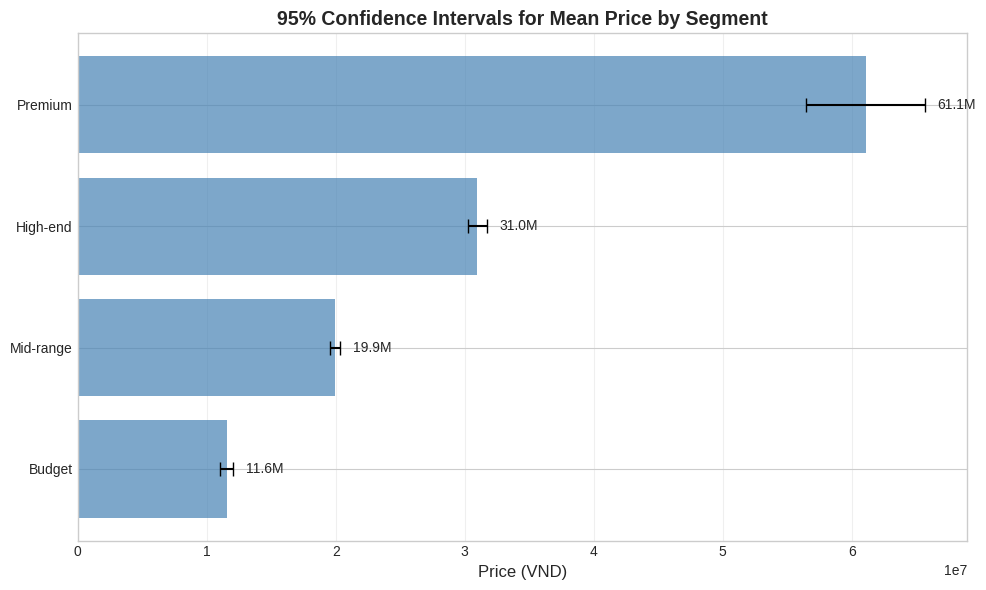

In [50]:
# Visualization 1: Confidence Intervals for Mean Price by Segment
fig, ax = plt.subplots(figsize=(10, 6))

segments = ['Budget', 'Mid-range', 'High-end', 'Premium']
means = []
lowers = []
uppers = []

for segment in segments:
    seg_data = df[df['Price_Segment'] == segment]['Price_VND']
    if len(seg_data) >= 5:
        m, l, h = calculate_ci_mean(seg_data, 0.95)
        means.append(m)
        lowers.append(l)
        uppers.append(h)
    else:
        means.append(0)
        lowers.append(0)
        uppers.append(0)

# Plot
y_pos = np.arange(len(segments))
errors = [[means[i] - lowers[i] for i in range(len(segments))],
          [uppers[i] - means[i] for i in range(len(segments))]]

ax.barh(y_pos, means, xerr=errors, alpha=0.7, capsize=5, color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(segments)
ax.set_xlabel('Price (VND)', fontsize=12)
ax.set_title('95% Confidence Intervals for Mean Price by Segment', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (m, l, h) in enumerate(zip(means, lowers, uppers)):
    if m > 0:
        ax.text(h + 1000000, i, f'{m/1e6:.1f}M', va='center', fontsize=10)

plt.tight_layout()
plt.show()

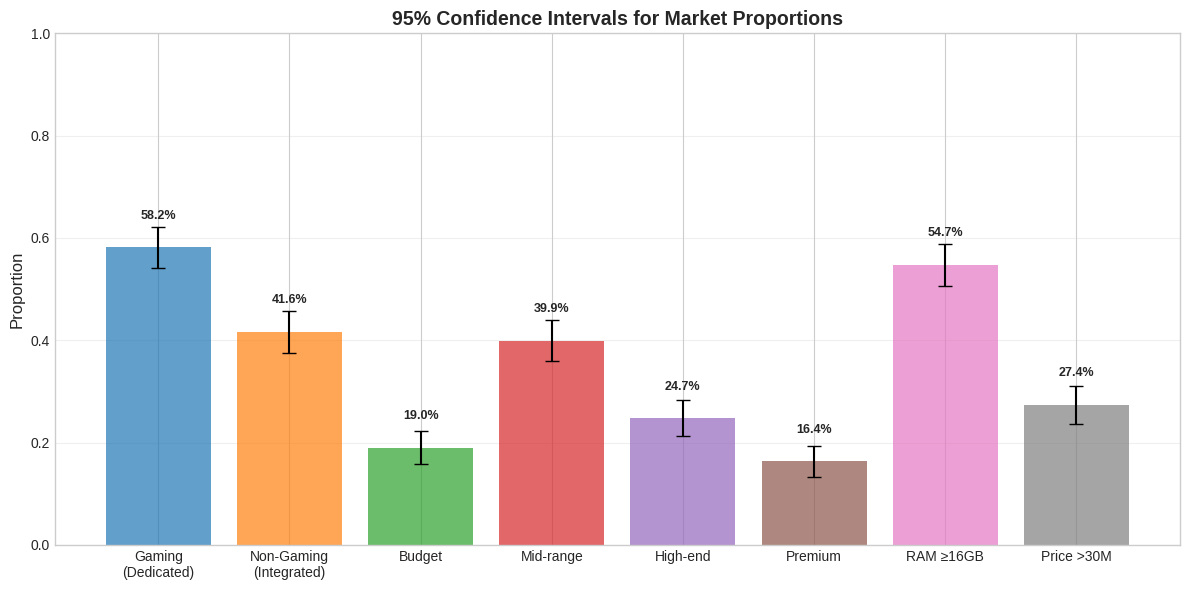

In [51]:
# Visualization 2: Proportion Estimates with CI
fig, ax = plt.subplots(figsize=(12, 6))

categories = ['Gaming\n(Dedicated)', 'Non-Gaming\n(Integrated)', 
              'Budget', 'Mid-range', 'High-end', 'Premium',
              'RAM ≥16GB', 'Price >30M']
props = []
ci_lows = []
ci_highs = []

# Calculate proportions
for i, cat in enumerate(['Dedicated', 'Integrated', 'Budget', 'Mid-range', 'High-end', 'Premium']):
    if i < 2:
        p, l, h = calculate_ci_prop(df['GPU_Type'], cat, 0.95)
    else:
        p, l, h = calculate_ci_prop(df['Price_Segment'], cat, 0.95)
    props.append(p)
    ci_lows.append(l)
    ci_highs.append(h)

# Additional metrics
p_ram16, l_ram16, h_ram16 = calculate_ci_prop(df['RAM_GB'] >= 16, True, 0.95)
props.append(p_ram16)
ci_lows.append(l_ram16)
ci_highs.append(h_ram16)

p_30m, l_30m, h_30m = calculate_ci_prop(df['Price_VND'] > 30000000, True, 0.95)
props.append(p_30m)
ci_lows.append(l_30m)
ci_highs.append(h_30m)

# Plot
x_pos = np.arange(len(categories))
errors = [[props[i] - ci_lows[i] for i in range(len(props))],
          [ci_highs[i] - props[i] for i in range(len(props))]]

bars = ax.bar(x_pos, props, yerr=errors, alpha=0.7, capsize=5, 
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f'])
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('95% Confidence Intervals for Market Proportions', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)

# Add value labels
for i, (p, bar) in enumerate(zip(props, bars)):
    ax.text(bar.get_x() + bar.get_width()/2, p + 0.05, f'{p*100:.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
# Kết luận

## Tổng kết kiến thức đã học:

### 1. Point Estimation (Ước lượng điểm)
- Sử dụng sample mean ($\bar{x}$) để ước lượng population mean ($\mu$)
- Sử dụng sample proportion ($\hat{p}$) để ước lượng population proportion ($p$)
- Ước lượng điểm cho một giá trị cụ thể nhưng không biểu thị độ tin cậy

### 2. Confidence Intervals (Khoảng tin cậy)
- **For Mean**: Sử dụng t-distribution khi $\sigma$ chưa biết
- **For Proportion**: Sử dụng Normal approximation khi $n\hat{p} \geq 10$ và $n(1-\hat{p}) \geq 10$
- Độ tin cậy càng cao → Khoảng tin cậy càng rộng
- Sample size càng lớn → Margin of error càng nhỏ (~ $1/\sqrt{n}$)

### 3. Sample Size Determination
- Để giảm margin of error xuống 1/2 → Cần tăng sample size lên 4 lần
- Trade-off giữa độ chính xác (smaller error) và chi phí thu thập dữ liệu

### 4. Bayes Theorem Applications
- Cập nhật xác suất dựa trên thông tin mới
- $P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$
- Quan trọng trong decision making và prediction

## Ứng dụng thực tế:
- Market research: Ước lượng thị phần, nhu cầu khách hàng
- Quality control: Kiểm soát tỷ lệ lỗi sản phẩm
- Clinical trials: Ước lượng hiệu quả thuốc, tác dụng phụ
- Business analytics: Dự đoán doanh thu, phân tích xu hướng

## Bài tập nâng cao (tự nghiên cứu):
1. Tìm hiểu về **Bootstrap method** để ước lượng CI khi không giả định phân phối
2. So sánh CI giữa hai nhóm độc lập (Two-sample CI)
3. Áp dụng **Bayesian estimation** thay vì Frequentist approach
4. Nghiên cứu về **Prediction Intervals** vs Confidence Intervals